# 1. Frequency Signal Generator

The frequency signal generator is defined as a function for later usage

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# Signal parameters ->picked to match real data (Aurnhammer et al., 2021)
sfreq = 500           # Hz
tmin  = -0.2          # seconds (epoch start)
tmax  = 1.2           # seconds (epoch end)
times = np.arange(tmin, tmax, 1.0 / sfreq)  # 700 samples
n_samples = len(times)

# define amplitudes for oscillations pre and post transition point (600ms)
theta_amp_pre=1.0    
delta_amp_pre=0.0    
theta_amp_post=0.0   
delta_amp_post=1.0




# function that generates the synthetic frequency signal
def generate_eeg_signal(
    times,
    sfreq=500,
    # Pre-transition profile (before t_switch) 
    theta_amp_pre=theta_amp_pre,     # theta amplitude in pre-window
    delta_amp_pre=delta_amp_pre,     # delta amplitude in pre-window
    # Post-transition profile (after t_switch)
    theta_amp_post=theta_amp_post,    # theta amplitude in post-window
    delta_amp_post=delta_amp_post,    # delta amplitude in post-window
    # Frequencies 
    theta_freq=5.5,        # Hz (center of theta band)
    delta_freq=2.5,        # Hz (center of delta band)
    # Transition 
    t_switch=0.6,          # transition center (s)
    mode='sequential',     # 'sequential' = instant switch, 'overlapping' = gradual
    overlap_window=0.15,    # half-width of overlap taper (s), used in 'overlapping' mode
    # --- Noise ---
    noise_amp=0.000,         # Gaussian noise amplitude
):
    """
    Generate a synthetic 1-channel EEG signal with configurable
    theta/delta profiles that transition at t_switch.

    Returns: 1D array of shape (n_samples,)
    """
    signal = np.zeros_like(times)

    #  Build amplitude envelopes 
    if mode == 'sequential':
        # Instant switch at t_switch
        pre_mask  = times < t_switch
        post_mask = times >= t_switch

        theta_env = np.where(pre_mask, theta_amp_pre, theta_amp_post)
        delta_env = np.where(pre_mask, delta_amp_pre, delta_amp_post)

    elif mode == 'overlapping':
        # Each band gets its OWN sigmoid, offset from t_switch so they genuinely overlap in the middle.
        #
        # overlap_window (s): how far each band extends into the
        # other's territory.  E.g. 0.15 
        #   theta tapers  600 ms - 750 ms
        #   delta ramps   450 ms - 600 ms
        #   overlap zone  450 ms – 750 ms (both active)

        steepness = 10.0 / overlap_window

        # Theta: high to low, sigmoid center AFTER t_switch
        theta_sig = 1.0 / (1.0 + np.exp(
            -steepness * (times - (t_switch + overlap_window / 2))))
        theta_env = theta_amp_pre * (1 - theta_sig) + theta_amp_post * theta_sig

        # Delta: low to high, sigmoid center BEFORE t_switch
        delta_sig = 1.0 / (1.0 + np.exp(
            -steepness * (times - (t_switch - overlap_window / 2))))
        delta_env = delta_amp_pre * (1 - delta_sig) + delta_amp_post * delta_sig
    else:
        raise ValueError(f"Unknown mode: {mode}. Use 'sequential' or 'overlapping'.")

    # Generate oscillations (phase-aligned to cross zero at t_switch) -> clean transition in sequential case
    theta_osc = theta_env * np.sin(2 * np.pi * theta_freq * (times - t_switch))
    delta_osc = delta_env * np.sin(2 * np.pi * delta_freq * (times - t_switch))

    signal = theta_osc + delta_osc

    # Add noise 
    if noise_amp > 0:
        signal += noise_amp * np.random.randn(len(times))

    return signal

# 2. Instantiating two signal configurations

The frequency signal generator is used to instantiate two signals for later wavelet transform

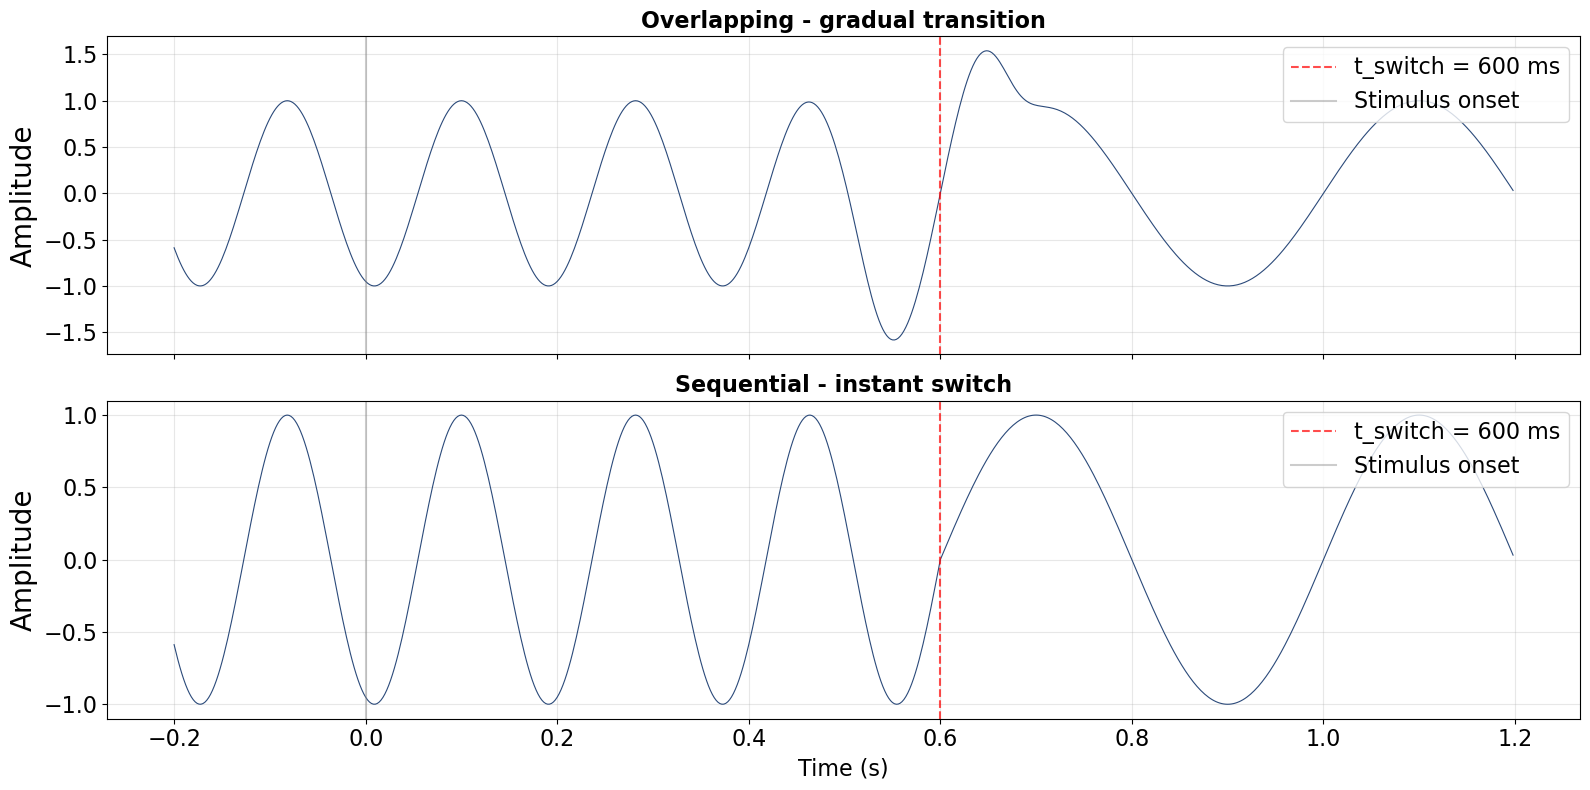

In [ ]:
np.random.seed(42) #reproducible results

# define the signal types to be created
configs = {
    'Overlapping - gradual transition': dict(mode='overlapping', overlap_window=0.15),
    'Sequential - instant switch': dict(mode='sequential'),
}

# Store signals for later wavelet analysis
sim_signals = {}

fig, axes = plt.subplots(len(configs), 1, figsize=(16, 4 * len(configs)), sharex=True)

for ax, (label, kwargs) in zip(axes, configs.items()):
    sig = generate_eeg_signal(times, sfreq=sfreq, **kwargs)
    sim_signals[label] = sig

    ax.plot(times, sig, color='#2B4A7A', linewidth=0.8)
    ax.axvline(x=0.6, color='red', linestyle='--', alpha=0.7, label='t_switch = 600 ms')
    ax.axvline(x=0.0, color='gray', linestyle='-', alpha=0.4, label='Stimulus onset')
    ax.set_ylabel('Amplitude', fontsize=20)
    ax.set_title(label, fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', fontsize=16)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=16)

axes[-1].set_xlabel('Time (s)', fontsize=16)

plt.tight_layout()
plt.show()



# 3. Wavelet transform on synthetic data

Complex Morlet Wavelet Transform is applied to the prior constructed signals.
Power estimates are extracted and plotted againts true power values.


  Wavelet analysis: Overlapping (gradual transition)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


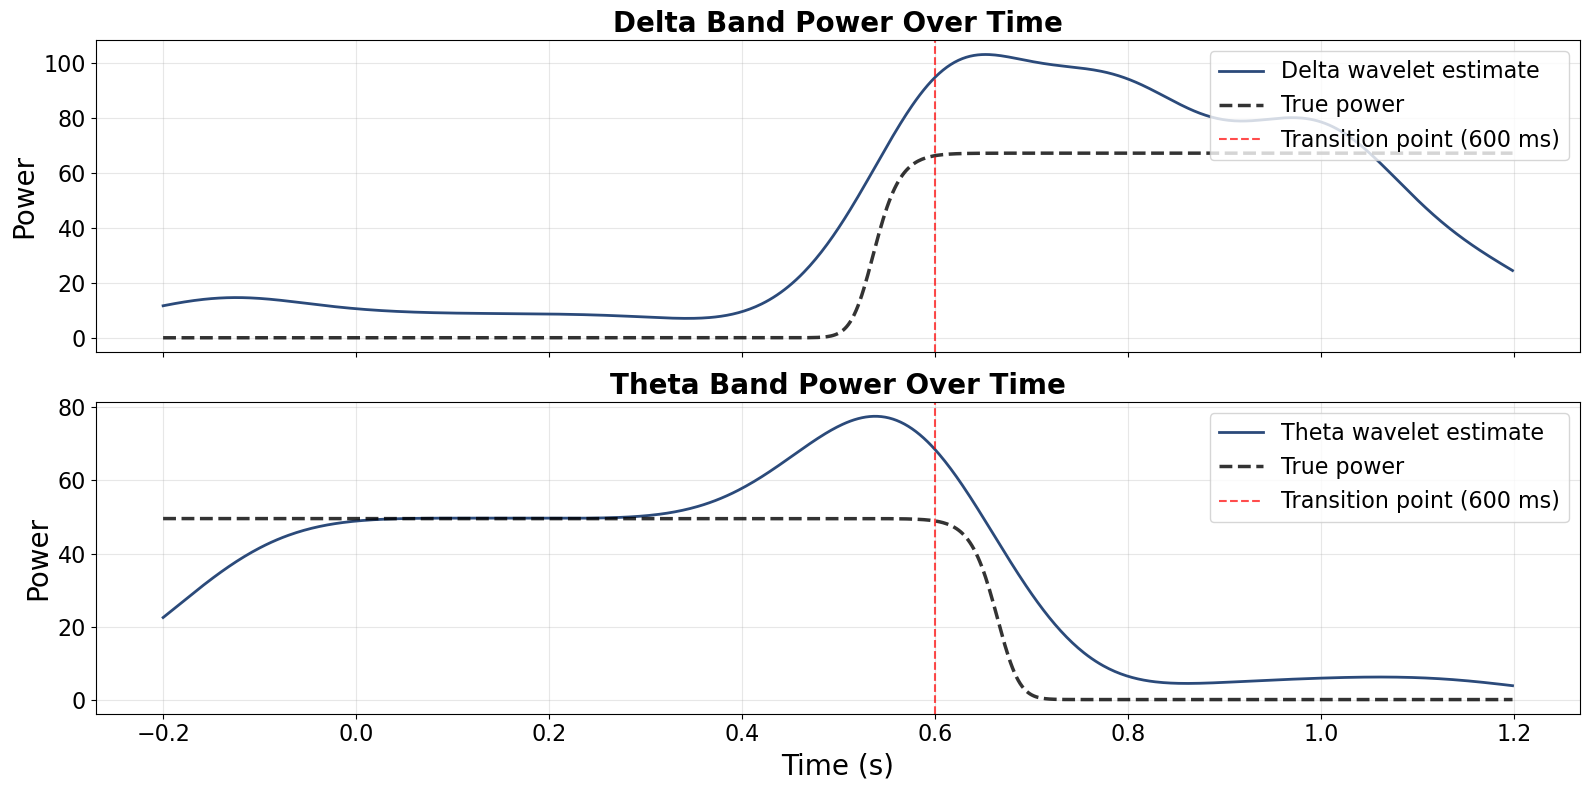


  Wavelet analysis: Sequential (instant switch)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


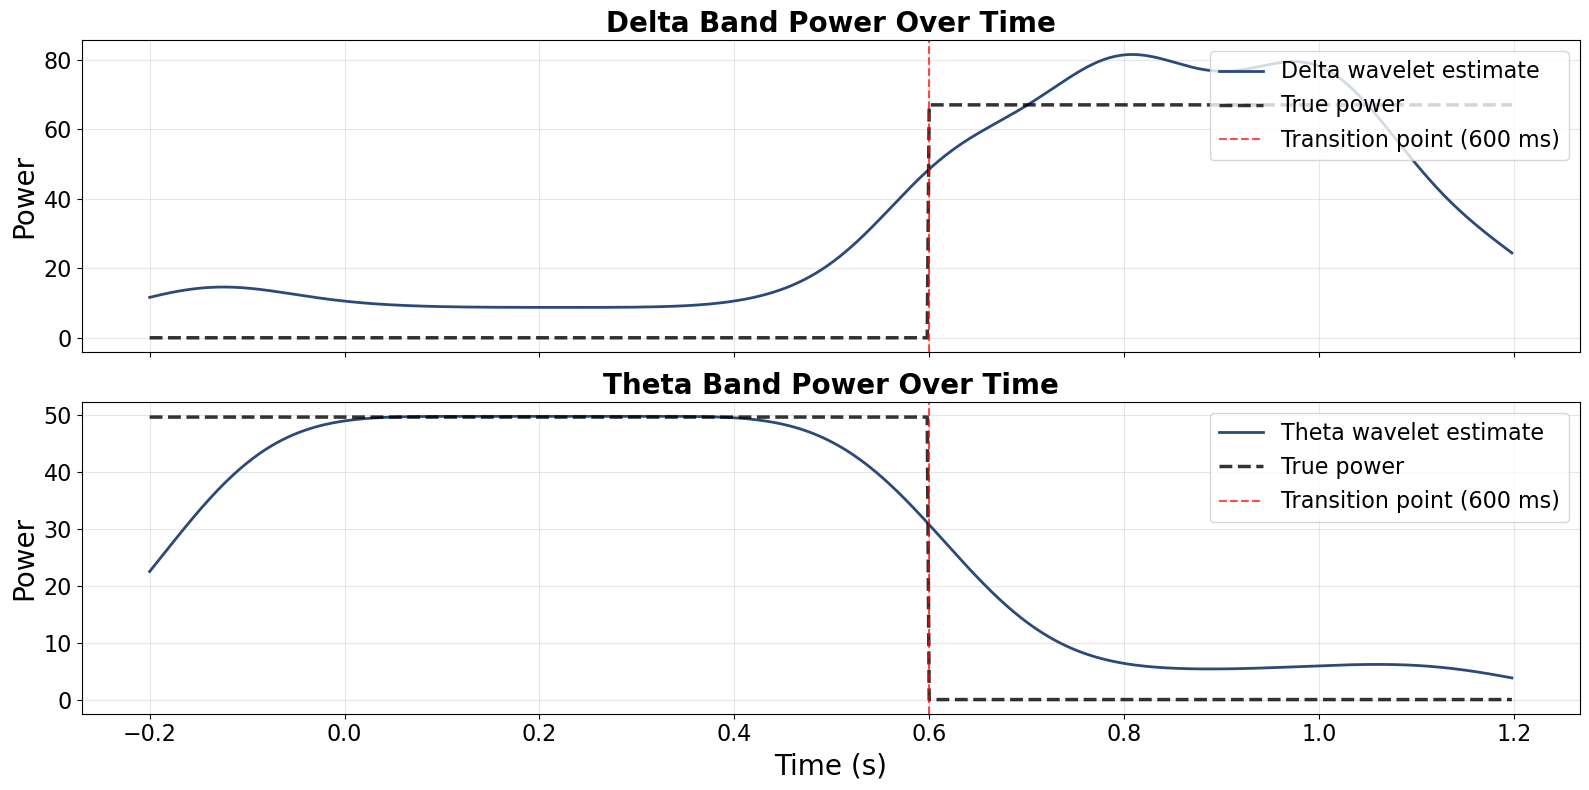

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ── TFR parameters (identical to section 2 of TFA notebook) ──
freqs    = np.arange(2, 31, 1)   # 2–30 Hz
scaling_factor = 1.2             # defines the width of the wavelet
n_cycles = freqs / scaling_factor # frequency adaptive wavelet cycle definition to keep 
decim    = 1                     # no decimation as this data is very computationally light

# Band definitions, only delta and theta are needed
BANDS = {
    'Delta': (2, 4),
    'Theta': (4, 8),
}

# ── Helper: compute band-average power time course ──
def compute_band_power(tfr_data, freqs, fmin, fmax):
    """Average power across frequency bins in [fmin, fmax]."""
    mask = (freqs >= fmin) & (freqs <= fmax)
    return tfr_data[0, mask, :].mean(axis=0)  # (n_times,)


#  Create MNE Info for 1-channel data 
info_sim = mne.create_info(ch_names=['Sim'], sfreq=sfreq, ch_types='eeg')


for label, sig in sim_signals.items():
    print(f"\n{'='*70}")
    print(f"  Wavelet analysis: {label}")
    print(f"{'='*70}")

    # Wrap signal into MNE EpochsArray to apply MNE wavelet transform (1 trial, 1 channel)
    data = sig[np.newaxis, np.newaxis, :]  # (1, 1, n_times)
    events = np.array([[0, 0, 1]])
    epochs = mne.EpochsArray(data, info_sim, events=events,
                             tmin=tmin, event_id={'stim': 1}, verbose=False)

    # Compute TFR 
    tfr = mne.time_frequency.tfr_morlet(
        epochs, freqs=freqs, n_cycles=n_cycles,
        use_fft=True, return_itc=False,
        decim=decim, n_jobs=1, average=True, verbose=False
    )

    tfr_times = tfr.times
    tfr_data  = tfr.data  # shape: (1, n_freqs, n_times)



    # Figure 1: Band-specific power time courses 
    fig, axes = plt.subplots(len(BANDS), 1, figsize=(16, 4 * len(BANDS)), sharex=True)

    for ax, (band_name, (fmin, fmax)) in zip(axes, BANDS.items()):
        band_power = compute_band_power(tfr_data, freqs, fmin, fmax)

    for ax, (band_name, (fmin, fmax)) in zip(axes, BANDS.items()):
        band_power = compute_band_power(tfr_data, freqs, fmin, fmax)

        # ── Reconstruct the TRUE amplitude envelope ──
        if band_name == 'Delta':
            amp_pre, amp_post = delta_amp_pre, delta_amp_post
        elif band_name == 'Theta':
            amp_pre, amp_post = theta_amp_pre, theta_amp_post
        else:
            amp_pre, amp_post = 1.0, 1.0

        sig_mode = configs[label].get('mode', 'sequential')

        if sig_mode == 'sequential':
            amp_envelope = np.where(tfr_times < 0.6, amp_pre, amp_post)
        else:  # overlapping — independent sigmoids, offset from t_switch
            ow = configs[label].get('overlap_window', 0.2)
            steepness = 10.0 / ow

            if band_name == 'Theta':
                sig = 1.0 / (1.0 + np.exp(
                    -steepness * (tfr_times - (0.6 + ow / 2))))
            else:  # Delta
                sig = 1.0 / (1.0 + np.exp(
                    -steepness * (tfr_times - (0.6 - ow / 2))))

            amp_envelope = amp_pre * (1 - sig) + amp_post * sig

        true_power = amp_envelope**2 / 2   # A²/2

        #  Convert true power to MNE wavelet units for better comparability
        # Use the HIGH-amplitude plateau (far from transition) to get the scale factor.
      
        high_amp = max(amp_pre, amp_post)
        if high_amp > 0:
            if amp_pre >= amp_post:
                # Band is dominant pre-transition
                wavelet_plateau = np.median(band_power[tfr_times < 0.3])
            else:
                # Band is dominant post-transition
                wavelet_plateau = np.median(band_power[tfr_times > 0.9])
            mne_scale = wavelet_plateau / (high_amp**2 / 2)
        else:
            mne_scale = 1.0

        true_power_mne = true_power * mne_scale

        # ── Plot both on the SAME axis, same units ──
        ax.plot(tfr_times, band_power, linewidth=2, color='#2B4A7A',
                label=f'{band_name} wavelet estimate')
        ax.plot(tfr_times, true_power_mne, color='black', linewidth=2.5,
                linestyle='--', alpha=0.8,
                label=f'True power')

        ax.axvline(x=0.6, color='red', linestyle='--', alpha=0.7,
                   label='Transition point (600 ms)')



        ax.set_ylabel('Power', fontsize=20)
        ax.set_title(f'{band_name} Band Power Over Time', fontsize=20, fontweight='bold')
        ax.legend(loc='upper right', fontsize=16)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='both', labelsize=16)

    axes[-1].set_xlabel('Time (s)', fontsize=20)

    plt.tight_layout()
    plt.show()


